In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
plt.rc('font', family = 'Malgun Gothic')

In [2]:
inventory_df = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\재고.csv")
sales_df = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\판매.csv")
order_df = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\발주.csv")

In [3]:
inventory_df.head()

,날짜,P1,P2,P3,P4,P5
0,2024-01-01,15,11,8,12,8
1,2024-01-02,13,9,6,8,7
2,2024-01-03,13,9,6,7,6
3,2024-01-04,10,6,5,7,6
4,2024-01-05,8,5,3,4,3


In [4]:
sales_df.head()

,날짜,P1,P2,P3,P4,P5
0,2024-01-01,3,4,3,4,3
1,2024-01-02,2,2,2,4,1
2,2024-01-03,0,0,0,1,1
3,2024-01-04,3,3,1,0,0
4,2024-01-05,2,1,2,3,3


In [5]:
order_df.head() # 해당 데이터에서 주문수량은 20개로 통일

,상품,주문날짜,배송날짜,수량
0,P3,2024-01-04,2024-01-08,20
1,P2,2024-01-05,2024-01-10,20
2,P3,2024-01-04,2024-01-08,20
3,P4,2024-01-05,2024-01-12,20
4,P5,2024-01-05,2024-01-12,20


In [14]:
# 현 재고관리 수준을 평가
order_df['리드타임(일)'] = (pd.to_datetime(order_df['배송날짜']) - pd.to_datetime(order_df['주문날짜'])).dt.days

In [17]:
order_df.groupby('상품')['리드타임(일)'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
상품,,,,,,,,
P1,175.0,6.83,0.79,5.0,6.0,7.0,7.0,8.0
P2,156.0,5.53,1.10,3.0,5.0,5.0,6.0,8.0
P3,144.0,5.36,1.70,1.0,4.0,5.0,6.0,8.0
P4,149.0,5.68,1.46,1.0,5.0,6.0,7.0,8.0
P5,176.0,6.65,0.89,4.0,6.0,7.0,7.0,8.0


<Axes: ylabel='상품'>

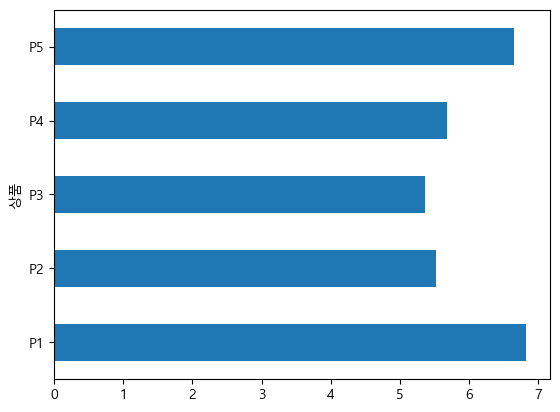

In [27]:
# 각 제품별 평균이 크게 다르지않아, 추가분석이 가능하다고 판단하여 추가분석 진행
order_df.groupby('상품')['리드타임(일)'].mean().sort_index().plot(kind = 'barh')

<Axes: xlabel='리드타임(일)', ylabel='Density'>

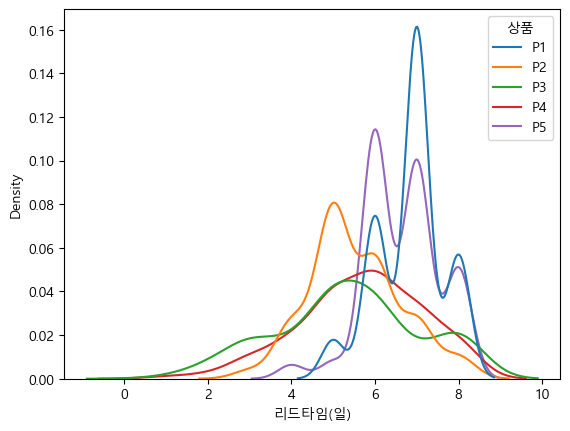

In [36]:
# .sort_values(by = '') >> 중요
# 이 그래프를 그렸던 이유는 위에 있는 barh 그래프도 각 제품별 리드타임(일)이 잘 보이지않는다면 보는 alternative tool.
sns.kdeplot(order_df.sort_values(by = '상품'), x = '리드타임(일)', hue = '상품')

In [37]:
inventory_df['날짜'] = pd.to_datetime(inventory_df['날짜'])

In [38]:
inventory_df.head()

,날짜,P1,P2,P3,P4,P5
0,2024-01-01,15,11,8,12,8
1,2024-01-02,13,9,6,8,7
2,2024-01-03,13,9,6,7,6
3,2024-01-04,10,6,5,7,6
4,2024-01-05,8,5,3,4,3


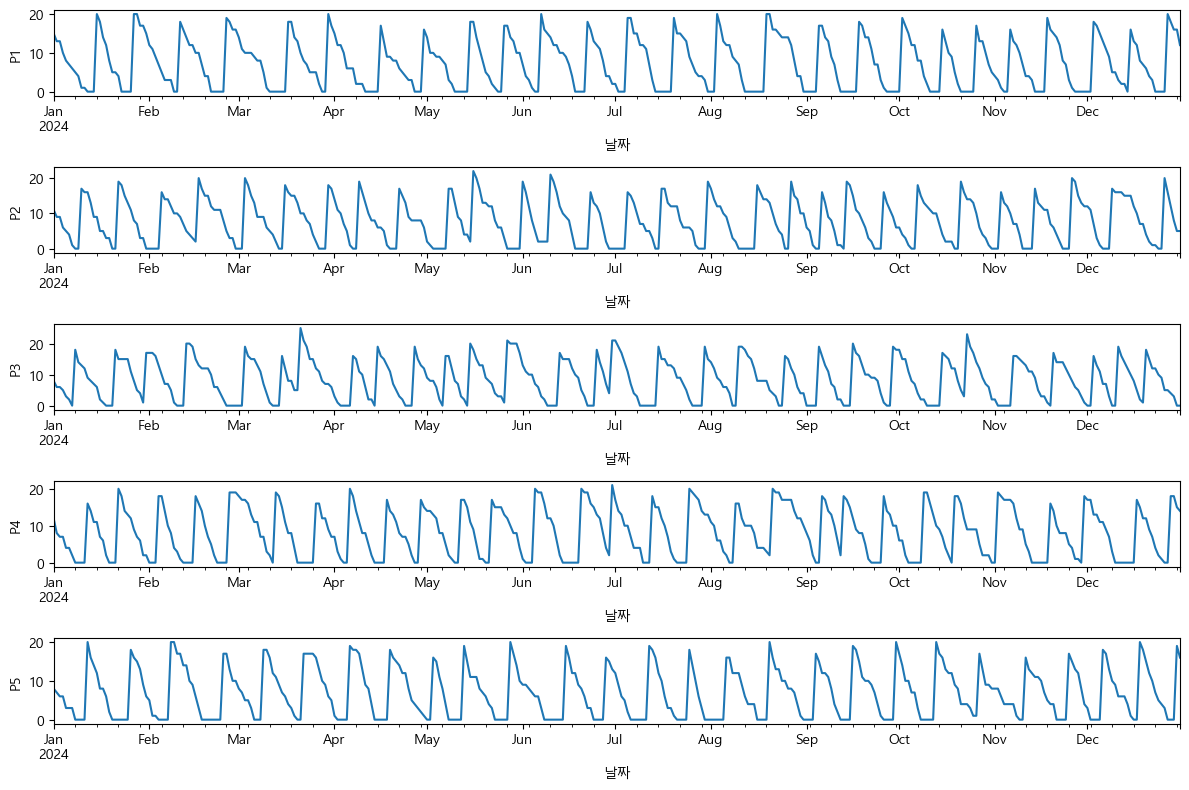

In [44]:
# 이 그래프는 위 테이블을 일별 상품별 재고수준을 시각화 하기 위함. 각각의 그래프를 그려 트렌드를 찾으려고 함.
fig, axes = plt.subplots(5, 1, figsize = (12, 8)) # 행이 5개, 열 1개
inventory_df.plot(ax = axes[0], x = '날짜', y = 'P1', legend = False, ylabel = 'P1') # legend(범례) 필요 x
inventory_df.plot(ax = axes[1], x = '날짜', y = 'P2', legend = False, ylabel = 'P2')
inventory_df.plot(ax = axes[2], x = '날짜', y = 'P3', legend = False, ylabel = 'P3')
inventory_df.plot(ax = axes[3], x = '날짜', y = 'P4', legend = False, ylabel = 'P4')
inventory_df.plot(ax = axes[4], x = '날짜', y = 'P5', legend = False, ylabel = 'P5')
plt.tight_layout() # 그림이 겹치지 않도록
# 아래데이터를 보면, 재고수준이 0이되는 트렌드가 지속 보인다. 즉 재고관점에서는 개선이 필요하다라는점 (여기서는 리드타임을 개선해서 미리 주문이 결론)

In [45]:
sales_df.head()

,날짜,P1,P2,P3,P4,P5
0,2024-01-01,3,4,3,4,3
1,2024-01-02,2,2,2,4,1
2,2024-01-03,0,0,0,1,1
3,2024-01-04,3,3,1,0,0
4,2024-01-05,2,1,2,3,3


In [46]:
sales_df['날짜'] = pd.to_datetime(sales_df['날짜'])

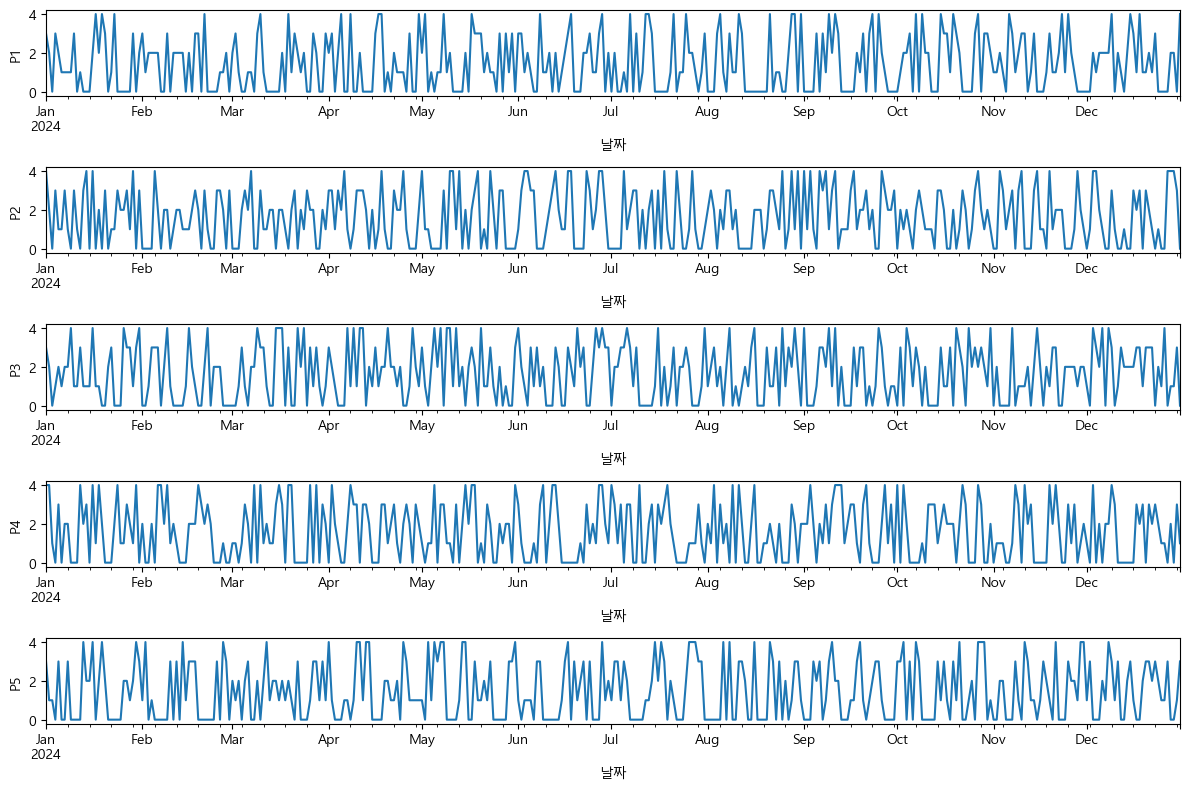

In [47]:
fig, axes = plt.subplots(5, 1, figsize = (12, 8)) # 행이 5개, 열 1개
sales_df.plot(ax = axes[0], x = '날짜', y = 'P1', legend = False, ylabel = 'P1') # legend(범례) 필요 x
sales_df.plot(ax = axes[1], x = '날짜', y = 'P2', legend = False, ylabel = 'P2')
sales_df.plot(ax = axes[2], x = '날짜', y = 'P3', legend = False, ylabel = 'P3')
sales_df.plot(ax = axes[3], x = '날짜', y = 'P4', legend = False, ylabel = 'P4')
sales_df.plot(ax = axes[4], x = '날짜', y = 'P5', legend = False, ylabel = 'P5')
plt.tight_layout()
# 판매량은 0 ~ 4까지를 범위내에서 움직임; 패턴이 잘 보이진 않는다

In [48]:
sales_df[['P1', 'P2', 'P3', 'P4', 'P5']].describe()
# 하기 데이터에서의 핵심은 min & 25% 구간이 0 이라는것. 즉. 판매가 0인데, 해석이 2개. 그 중 한개는 재고가 없어서 판매가 발생못함

,P1,P2,P3,P4,P5
count,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1.437158,1.612022,1.669399,1.590164,1.461749
std,1.423920,1.411214,1.407414,1.456704,1.458996
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,2.000000,1.000000,1.000000
75%,3.000000,3.000000,3.000000,3.000000,3.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000


In [49]:
# 재고부족 현황
no_inventory = inventory_df[['P1', 'P2', 'P3', 'P4', 'P5']] == 0
no_inventory.sum() # 재고가 없었던

P1    104
P2     81
P3     73
P4     85
P5    111
dtype: int64

In [51]:
# 재고가 없었거나, 고객이 없어 하나도 안 팔렸거나를 합치면.
no_sales = sales_df[['P1', 'P2', 'P3', 'P4', 'P5']] == 0
no_sales.sum() # 재고부족과 고객없음의 비중산출 가능

P1    140
P2    114
P3    106
P4    127
P5    142
dtype: int64

In [64]:
# 재고가 있을때 평균 재고량 (재고가 0일때는 배제하고 본다.)
print(inventory_df.loc[inventory_df['P1'] != 0, 'P1'].mean())
print(inventory_df.loc[inventory_df['P2'] != 0, 'P2'].mean())
print(inventory_df.loc[inventory_df['P3'] != 0, 'P3'].mean())
print(inventory_df.loc[inventory_df['P4'] != 0, 'P4'].mean())
print(inventory_df.loc[inventory_df['P5'] != 0, 'P5'].mean())

10.106870229007633
9.79298245614035
10.372013651877133
10.647686832740213
9.898039215686275


In [65]:
# 재고가 있을때 평균 판매량 (재고가 0일때는 배제하고 본다.)
print(sales_df.loc[sales_df['P1'] != 0, 'P1'].mean())
print(sales_df.loc[sales_df['P2'] != 0, 'P2'].mean())
print(sales_df.loc[sales_df['P3'] != 0, 'P3'].mean())
print(sales_df.loc[sales_df['P4'] != 0, 'P4'].mean())
print(sales_df.loc[sales_df['P5'] != 0, 'P5'].mean())

2.327433628318584
2.3412698412698414
2.35
2.435146443514644
2.388392857142857


In [ ]:
## Q2. 모든상품에 대해 3일주기로 5개의 상품을 주문하는 주기적 주문방식을 채택한다면, 기존방식 대비 효과가 좋을지를 평가
       # 단, 판매량과 리드타임은 정규분포를 따른다고 가정하여 난수를 생성하고, 자연수로 변환합니다.

In [67]:
leadtime_mean_std = {'P1' : [6.83, 0.79], ## 처음으로 {} 과 : 을 썼다. 왜?? [] = square bracket <> {} = curly brace
                     'P2' : [5.53, 1.10],
                     'P3' : [5.36, 1.70],
                     'P4' : [5.68, 1.46],
                     'P5' : [6.65, 0.89]}

In [74]:
sales_mean_std = {'P1' : [sales_df.loc[sales_df['P1'] !=0, 'P1'].mean(), sales_df.loc[sales_df['P1'] !=0, 'P1'].std()], # 0 (재고없음)을 뺀다
                 'P2' : [sales_df.loc[sales_df['P2'] !=0, 'P2'].mean(), sales_df.loc[sales_df['P2'] !=0, 'P1'].std()],
                 'P3' : [sales_df.loc[sales_df['P3'] !=0, 'P3'].mean(), sales_df.loc[sales_df['P3'] !=0, 'P1'].std()],
                 'P4' : [sales_df.loc[sales_df['P4'] !=0, 'P4'].mean(), sales_df.loc[sales_df['P4'] !=0, 'P1'].std()],
                 'P5' : [sales_df.loc[sales_df['P5'] !=0, 'P5'].mean(), sales_df.loc[sales_df['P5'] !=0, 'P1'].std()]}

In [86]:
new_inventory_df = pd.DataFrame() # 빈 데이터 Frame 생성
for item in ['P1', 'P2', 'P3', 'P4', 'P5']:
    inventory_list = [inventory_df[item].iloc[0]] # 첫날 가지고 있는 재고량
    order_time_list = []
    for i in range(364): # 1년 365일이나 0부터 시작
        current_inventory = inventory_list[-1] #하 하루 전 마감 재고
        if i in order_time_list: # 전날재고수준 반영
            current_inventory += 5

        sales = max([int(np.random.normal(sales_mean_std[item][0], sales_mean_std[item][1])), 0]) # 시나리오 Run하는 np thread + int & max 를 사용해 음수가능성 제거
        if sales >= current_inventory: # 판매량 반영
            current_inventory = 0
        else: 
            current_inventory -= sales

        if i % 3 == 0: # if 3으로 나눴을때 나머지가 0이면 (3일주기주문을 코드화)
            leadtime = int(np.random.normal(leadtime_mean_std[item][0], leadtime_mean_std[item][1])) # 시나리오 Run하는 np thread
            order_time_list.append(i+leadtime)

        inventory_list.append(current_inventory)
    new_inventory_df[item] = inventory_list # 이거 윗 부분과 동일한 위치에서 시작했더니 오류가 났다... ㅜㅜ

In [88]:
new_inventory_df.head()

,P1,P2,P3,P4,P5
0,15,11,8,12,8
1,14,7,7,11,6
2,13,5,6,10,6
3,12,5,1,8,2
4,8,4,0,5,2


In [91]:
# 기존과 비교하기
prev_no_inventory = inventory_df[['P1', 'P2', 'P3', 'P4', 'P5']] == 0
new_no_inventory = new_inventory_df[['P1', 'P2', 'P3', 'P4', 'P5']] == 0

<Axes: >

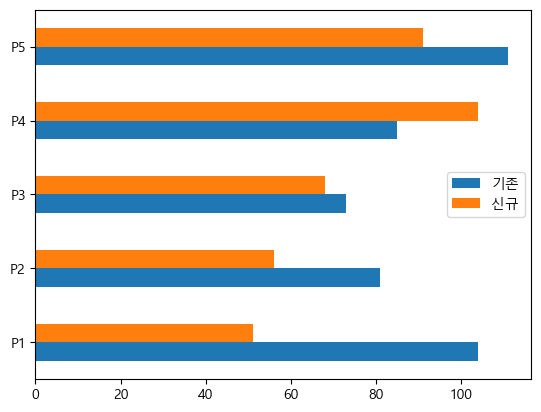

In [98]:
# 과거와 현재 재고를 합쳐보자.
no_inventory = pd.concat([prev_no_inventory.sum(), new_no_inventory.sum()], axis = 1) # 행방향으로 되어있는것을 열방향으로 합친다??ㅜㅜ
no_inventory.columns = ['기존', '신규']
no_inventory.sort_index().plot(kind = 'barh')
# 아래그래프 해석해보면, 신규때 재고가 없었던 날짜갯수가 신규가 P4를 제외하고는 전부 작아, 이 모델은 '재고없음' 관점에서 보면 나은방향이다

In [99]:
# 비교목적: 재고가 있을때 평균 재고량 (재고가 0일때는 배제하고 본다.)
print(inventory_df.loc[inventory_df['P1'] != 0, 'P1'].mean())
print(inventory_df.loc[inventory_df['P2'] != 0, 'P2'].mean())
print(inventory_df.loc[inventory_df['P3'] != 0, 'P3'].mean())
print(inventory_df.loc[inventory_df['P4'] != 0, 'P4'].mean())
print(inventory_df.loc[inventory_df['P5'] != 0, 'P5'].mean())

10.106870229007633
9.79298245614035
10.372013651877133
10.647686832740213
9.898039215686275


In [100]:
print(new_inventory_df.loc[new_inventory_df['P1'] != 0, 'P1'].mean())
print(new_inventory_df.loc[new_inventory_df['P2'] != 0, 'P2'].mean())
print(new_inventory_df.loc[new_inventory_df['P3'] != 0, 'P3'].mean())
print(new_inventory_df.loc[new_inventory_df['P4'] != 0, 'P4'].mean())
print(new_inventory_df.loc[new_inventory_df['P5'] != 0, 'P5'].mean())
# 재고관점에서도 이 모델을 쓰면 개선가능하다 (평균 10개에서 5개 수준으로 감소; 재고효율화)

5.671974522292993
6.407766990291262
6.30976430976431
4.103448275862069
4.266423357664234


In [102]:
# Avg. 재고개선효과를 시각화시키기 위해
avg_inventory = []
for item in ['P1', 'P2', 'P3', 'P4', 'P5']:
    record = [inventory_df.loc[inventory_df[item] !=0, item].mean(),
              new_inventory_df.loc[new_inventory_df[item] !=0, item].mean()]
    avg_inventory.append(record)
avg_inventory = pd.DataFrame(avg_inventory, columns = ['신규', '기존'], index = ['P1', 'P2', 'P3', 'P4', 'P5'])

## avg_inventory.plot(kind = 'barh')